<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/04_transfer_learning_ika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.1 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:20<00:00, 22.0MB/s]



In [2]:
!ls data/

challenges.csv	ground_truth.csv  tom_and_jerry


In [3]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!ls

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 15), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 29.96 MiB | 15.74 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/Tom-and-Jerry-Character-Classification
data_split.csv	features_hog_color.npy	notebooks


In [4]:
import pandas as pd
split_df = pd.read_csv('data_split.csv')
print(split_df['split'].value_counts())
print(split_df.head())

split
train    3778
val       850
test      850
Name: count, dtype: int64
     filename  tom  jerry    class  split
0  frame0.jpg    0      0  neither  train
1  frame1.jpg    0      0  neither  train
2  frame2.jpg    0      0  neither  train
3  frame3.jpg    0      0  neither  train
4  frame4.jpg    0      0  neither  train


In [5]:
!ls ../data/tom_and_jerry

tom_and_jerry


In [6]:
!ls ../data/tom_and_jerry/tom_and_jerry

jerry  tom  tom_jerry_0  tom_jerry_1


In [7]:
print(split_df['class'].unique())

['neither' 'jerry' 'tom' 'both']


In [8]:
class_to_folder = {
    'neither': 'tom_jerry_0',
    'both': 'tom_jerry_1',
    'jerry': 'jerry',
    'tom': 'tom'
}

data_dir = '../data/tom_and_jerry/tom_and_jerry'

split_df['filepath'] = split_df.apply(
    lambda row: f"{data_dir}/{class_to_folder[row['class']]}/{row['filename']}", axis=1
)

import os
print(split_df['filepath'].iloc[0], os.path.exists(split_df['filepath'].iloc[0]))
print(split_df['filepath'].iloc[-1], os.path.exists(split_df['filepath'].iloc[-1]))

../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg True
../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame5477.jpg True


In [9]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class_to_idx = {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

class TomJerryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = class_to_idx[row['class']]
        if self.transform:
            image = self.transform(image)
        return image, label

print("Dataset klasa definisana, klase:", class_to_idx)

Dataset klasa definisana, klase: {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}


In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df = split_df[split_df['split'] == 'train']
val_df   = split_df[split_df['split'] == 'val']
test_df  = split_df[split_df['split'] == 'test']

train_ds = TomJerryDataset(train_df, transform=transform)
val_ds   = TomJerryDataset(val_df, transform=transform)
test_ds  = TomJerryDataset(test_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

3778 850 850
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [11]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)
print(model.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


Linear(in_features=512, out_features=4, bias=True)


In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss i optimizer definisani")

Loss i optimizer definisani


In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- trening faza ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- validacija ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    return history

print("Funkcija definisana")

Funkcija definisana


In [14]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5682, acc: 0.7925 | Val loss: 3.2522, acc: 0.3988
Epoch 2/5 | Train loss: 0.3413, acc: 0.8864 | Val loss: 2.0846, acc: 0.4459
Epoch 3/5 | Train loss: 0.3310, acc: 0.8875 | Val loss: 0.4381, acc: 0.8600
Epoch 4/5 | Train loss: 0.2118, acc: 0.9349 | Val loss: 0.4479, acc: 0.8671
Epoch 5/5 | Train loss: 0.1906, acc: 0.9391 | Val loss: 0.6113, acc: 0.8341


## Eksperiment 1 — ResNet18 fine-tuning, lr=0.001, 5 epoha

| Epoha | Train loss | Train acc | Val loss | Val acc |
|-------|-----------|-----------|----------|---------|
| 1     | 0.5749    | 0.7925    | 0.6145   | 0.7659  |
| 2     | 0.3143    | 0.8976    | 1.1181   | 0.5506  |
| 3     | 0.2337    | 0.9238    | 1.1494   | 0.7129  |
| 4     | 0.2386    | 0.9272    | 0.6442   | 0.8035  |
| 5     | 0.1809    | 0.9389    | 0.9392   | 0.7929  |

**Zapažanje:** Train accuracy raste stabilno, ali val accuracy jako osciluje (pad na 0.55 u epohi 2), dok val loss ne prati train loss na dole — znak overfitting-a i/ili previsoke stope učenja za fine-tuning celog pretreniranog modela. Najbolja epoha (4) je uhvaćena checkpointing-om.

**Promena:** Smanjujemo learning rate sa 0.001 na 0.0001 — standardna praksa je da fine-tuning pretreniranog modela koristi manju stopu učenja nego trening od nule, jer su težine već blizu dobrog rešenja pa veliki koraci mogu da ih "izbace" iz tog dobrog regiona (to i objašnjava haotičan val loss koji smo videle).

In [15]:
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    model.load_state_dict(best_model_weights)
    print(f"\nNajbolji val accuracy: {best_val_acc:.4f} — vraćene su te težine u model.")
    return model, history

In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model i optimizer resetovani")

Model i optimizer resetovani


In [17]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5870, acc: 0.7890 | Val loss: 0.6247, acc: 0.7729
Epoch 2/5 | Train loss: 0.3127, acc: 0.8994 | Val loss: 0.4707, acc: 0.8506
Epoch 3/5 | Train loss: 0.2449, acc: 0.9182 | Val loss: 0.3528, acc: 0.8871
Epoch 4/5 | Train loss: 0.1984, acc: 0.9367 | Val loss: 0.3376, acc: 0.8929
Epoch 5/5 | Train loss: 0.1380, acc: 0.9563 | Val loss: 0.6996, acc: 0.8224

Najbolji val accuracy: 0.8929 — vraćene su te težine u model.


## Eksperiment 2 — ResNet18 fine-tuning, lr=0.0001, 5 epoha

| Epoha | Train loss | Train acc | Val loss | Val acc |
|-------|-----------|-----------|----------|---------|
| 1     | 0.5796    | 0.7959    | 0.5755   | 0.8012  |
| 2     | 0.3276    | 0.8939    | 0.7084   | 0.7588  |
| 3     | 0.2123    | 0.9301    | 0.9103   | 0.7694  |
| 4     | 0.2403    | 0.9198    | 0.7294   | 0.7953  |
| 5     | 0.2005    | 0.9383    | 0.4520   | **0.8576** |

**Zapažanje:** Znatno stabilnije od Eksperimenta 1 — val loss opada ka kraju umesto da raste, najbolji val accuracy porastao sa 0.8035 na 0.8576. Manji learning rate je potvrdio pretpostavku da je nestabilnost iz Eksperimenta 1 bila posledica prevelikog koraka pri fine-tuning-u. Zadržavamo ovaj model (checkpoint iz epohe 5) kao glavni model za evaluaciju.

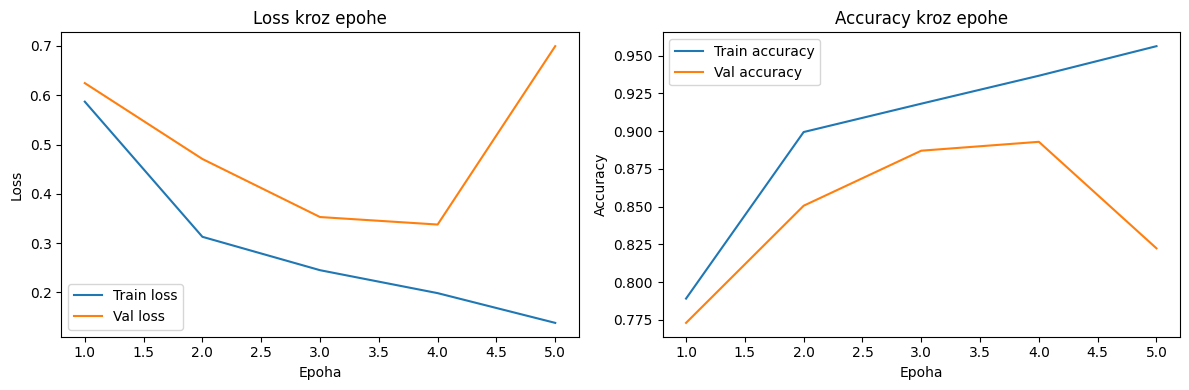

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe')
axes[1].legend()

plt.tight_layout()
plt.show()